In [108]:
import pandas as pd
from pathlib import Path

# 1) Oracle Summaries laden
oracle_dir = Path("./results")  # anpassen
files = sorted(oracle_dir.glob("summary_*.csv"))

oracle = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)

# Vereinheitlichen: nur Datum
#oracle["day"] = pd.to_datetime(oracle["day"], errors="coerce").dt.normalize()

oracle["day"] = pd.to_datetime(oracle["day"].astype(str).str.slice(0, 10), errors="coerce")
oracle["day"] = oracle["day"].dt.normalize()

# 2) RI_base aus combo_id==0 ziehen
ri_base = (
    oracle.loc[oracle["combo_id"] == 0, ["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
    .drop_duplicates(subset=["day"])
)

# 3) Alle "synthetic" Runs (ohne combo 0)
syn = oracle.loc[oracle["combo_id"] != 0].copy()

# 4) Baseline an synthetic dranhängen
syn = syn.merge(ri_base, on="day", how="left")

# Prozentualer uplift je combo
syn["uplift_pct"] = (syn["profit"] - syn["RI_base"]) / syn["RI_base"] * 100

# 5) Tages-Übersicht bauen
summary = (
    syn.groupby("day")
    .apply(lambda g: pd.Series({
        "RI_base": g["RI_base"].iloc[0],
        "Oracle_max": g["profit"].max(),
        "Oracle_max_pct": (g["profit"].max() - g["RI_base"].iloc[0]) / g["RI_base"].iloc[0] * 100,
        "n_better_than_base": (g["profit"] > g["RI_base"]).sum(),
        "mean_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].mean(),
        "median_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].median(),
    }))
    .reset_index()
)

# Optional: NaNs (falls kein Run besser ist) auf 0 setzen
summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]] = (
    summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]].fillna(0.0)
)

# Speichern
out_path = oracle_dir / "oracle_overview_by_day.csv"
summary.to_csv(out_path, index=False)

print("Saved:", out_path)
summary.head()



Saved: results/oracle_overview_by_day.csv


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_5152/651396625.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,day,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better
0,2019-01-01,68.233139,119.010039,74.416772,142.0,21.450609,17.686777
1,2019-01-02,159.440419,211.961910,32.941140,168.0,16.861342,17.855675
2,2019-01-03,56.598649,70.577425,24.698074,38.0,7.912128,5.888537
3,2019-01-04,64.915423,81.637881,25.760378,29.0,5.272558,3.797980
4,2019-01-05,102.020127,123.676087,21.227145,3.0,12.765820,10.157263


In [109]:
summary.describe()

,day,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2019-12-31 12:00:00,82.547940,109.038350,37.679523,103.036986,13.191745,11.713463
min,2019-01-01 00:00:00,17.538780,31.561290,-1.555101,0.000000,0.000000,0.000000
25%,2019-07-02 06:00:00,51.994373,69.590302,15.446276,42.000000,5.368461,4.460272
50%,2019-12-31 12:00:00,69.858306,91.182954,27.143603,86.000000,8.898897,7.453887
75%,2020-06-30 18:00:00,96.767080,124.966395,44.747852,156.000000,14.275333,12.354061
max,2020-12-30 00:00:00,905.855102,1156.318012,750.577376,298.000000,402.344045,416.017609
std,NaN,55.117335,74.743045,48.334166,75.108920,20.940813,21.041175


In [101]:
summary.to_csv(oracle_dir / "oracle_overview_summary_stats.csv", index=False)

In [ ]:
"""

from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("./results")  # <- anpassen
SUMMARY_GLOB = "summary_*.csv"

TRADES_ROOT = RESULTS_DIR / "trades"

def weighted_avg_price(df: pd.DataFrame) -> float:
    #VWAP über quantity; gibt NaN zurück, wenn df leer ist.
    if df.empty:
        return np.nan
    q = df["quantity"].astype(float).to_numpy()
    p = df["price"].astype(float).to_numpy()
    denom = q.sum()
    if denom <= 0:
        return np.nan
    return float((q * p).sum() / denom)

def enrich_one_day_summary(summary_path: Path) -> None:
    summary = pd.read_csv(summary_path)

    # day als Datum normalisieren
    summary["day"] = pd.to_datetime(summary["day"], errors="coerce").dt.normalize()
    day = summary["day"].iloc[0]
    if pd.isna(day):
        raise ValueError(f"Could not parse day in {summary_path}")

    # Day-ahead clearing timestamp (Europe/Berlin)
    # (Vortag 13:00)
    da_exec = (pd.Timestamp(day) - pd.Timedelta(days=1)).replace(hour=13)
    #da_exec = da_exec.tz_localize("Europe/Berlin")

    day_folder = TRADES_ROOT / f"{pd.Timestamp(day):%Y-%m-%d}"
    if not day_folder.exists():
        raise FileNotFoundError(f"Trades folder missing: {day_folder}")

    da_profit_list = []
    da_buy_price_list = []
    da_sell_price_list = []
    da_buy_qty_list = []
    da_sell_qty_list = []

    for _, row in summary.iterrows():
        combo_id = int(row["combo_id"])
        trades_file = day_folder / f"trades_combo_{combo_id:03d}.csv"

        if not trades_file.exists():
            # Falls einzelne Dateien fehlen: NaNs
            da_profit_list.append(np.nan)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            da_buy_qty_list.append(np.nan)
            da_sell_qty_list.append(np.nan)
            continue

        trades = pd.read_csv(trades_file)

        # execution_time & product parsen (TZ robust)
        # utc=True schluckt +01:00/+02:00 sauber, danach nach Berlin.
        trades["execution_time"] = pd.to_datetime(trades["execution_time"], errors="coerce", utc=True).dt.tz_convert("Europe/Berlin")
        # optional, falls du product später brauchst:
        # trades["product"] = pd.to_datetime(trades["product"], errors="coerce", utc=True).dt.tz_convert("Europe/Berlin")

        # 1) Prefer market-Spalte, falls vorhanden
        if "market" in trades.columns:
            da = trades.loc[trades["market"].astype(str) == "DA"].copy()
        else:
            # 2) Fallback: execution_time == DA clearing time
            da = trades.loc[trades["execution_time"] == da_exec].copy()

        if da.empty:
            # Baseline (combo 0) oder falls DA-Trades nicht geloggt
            da_profit_list.append(0.0)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            continue

        da_buy = da.loc[da["side"] == "buy"]
        da_sell = da.loc[da["side"] == "sell"]

        da_profit = float(pd.to_numeric(da["profit"], errors="coerce").fillna(0.0).sum())
        da_buy_price = weighted_avg_price(da_buy)
        da_sell_price = weighted_avg_price(da_sell)

        da_profit_list.append(da_profit)
        da_buy_price_list.append(da_buy_price)
        da_sell_price_list.append(da_sell_price)

    # Neue Spalten anfügen
    summary["da_exec_time"] = da_exec.tz_localize(None)  # nice for csv
    summary["da_profit"] = da_profit_list
    summary["da_buy_price"] = da_buy_price_list
    summary["da_sell_price"] = da_sell_price_list


    # Anteil am Gesamtprofit (vorsichtig bei 0)
    summary["da_profit_share"] = np.where(
        pd.to_numeric(summary["profit"], errors="coerce").abs() > 1e-9,
        summary["da_profit"] / pd.to_numeric(summary["profit"], errors="coerce"),
        np.nan
    ).round(2)

    # Speichern (neue Datei, damit du nichts verlierst)
    out_path = summary_path.with_name(summary_path.stem + ".csv")
    summary.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

def enrich_all():
    files = sorted(RESULTS_DIR.glob(SUMMARY_GLOB))
    print(f"Found {len(files)} summary files")
    for f in files:
        enrich_one_day_summary(f)

enrich_all()
"""

Found 730 summary files
Saved: results/summary_2019-01-01.csv
Saved: results/summary_2019-01-02.csv
Saved: results/summary_2019-01-03.csv
Saved: results/summary_2019-01-04.csv
Saved: results/summary_2019-01-05.csv
Saved: results/summary_2019-01-06.csv
Saved: results/summary_2019-01-07.csv
Saved: results/summary_2019-01-08.csv
Saved: results/summary_2019-01-09.csv
Saved: results/summary_2019-01-10.csv
Saved: results/summary_2019-01-11.csv
Saved: results/summary_2019-01-12.csv
Saved: results/summary_2019-01-13.csv
Saved: results/summary_2019-01-14.csv
Saved: results/summary_2019-01-15.csv
Saved: results/summary_2019-01-16.csv
Saved: results/summary_2019-01-17.csv
Saved: results/summary_2019-01-18.csv
Saved: results/summary_2019-01-19.csv
Saved: results/summary_2019-01-20.csv
Saved: results/summary_2019-01-21.csv
Saved: results/summary_2019-01-22.csv
Saved: results/summary_2019-01-23.csv
Saved: results/summary_2019-01-24.csv
Saved: results/summary_2019-01-25.csv
Saved: results/summary_201

In [118]:
import pandas as pd
from pathlib import Path

SUMMARY_DIR = Path("./results")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))

df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)

df["day"] = pd.to_datetime(df["day"]).dt.normalize()


ValueError: Tz-aware datetime.datetime cannot be converted to datetime64 unless utc=True, at position 90

#### Results analysis

In [119]:
df

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,da_profit_share
0,2019-01-01 00:00:00+01:00,0,no_da,NaN,NaN,68.233139,2018-12-31 13:00:00,0.0000,NaN,NaN,0.00
1,2019-01-01 00:00:00+01:00,1,buy_only,1.0,NaN,61.759133,2018-12-31 13:00:00,-28.3200,28.32,NaN,-0.46
2,2019-01-01 00:00:00+01:00,2,buy_only,2.0,NaN,60.593526,2018-12-31 13:00:00,-10.0700,10.07,NaN,-0.17
3,2019-01-01 00:00:00+01:00,3,buy_only,3.0,NaN,80.214991,2018-12-31 13:00:00,4.0800,-4.08,NaN,0.05
4,2019-01-01 00:00:00+01:00,4,buy_only,4.0,NaN,69.708946,2018-12-31 13:00:00,9.9100,-9.91,NaN,0.14
...,...,...,...,...,...,...,...,...,...,...,...
218995,2020-12-30 00:00:00+01:00,295,buy_sell,21.0,23.0,77.992064,2020-12-29 13:00:00,-15.2108,52.38,43.22,-0.20
218996,2020-12-30 00:00:00+01:00,296,buy_sell,21.0,24.0,78.156037,2020-12-29 13:00:00,-20.1902,52.38,37.43,-0.26
218997,2020-12-30 00:00:00+01:00,297,buy_sell,22.0,23.0,50.006117,2020-12-29 13:00:00,-9.7108,46.88,43.22,-0.19
218998,2020-12-30 00:00:00+01:00,298,buy_sell,22.0,24.0,49.320782,2020-12-29 13:00:00,-14.6902,46.88,37.43,-0.30


In [120]:
ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)

df = df.merge(ri_base, on="day", how="left")

df["uplift_abs"] = df["profit"] - df["RI_base"]
df["uplift_pct"] = df["uplift_abs"] / df["RI_base"]


In [121]:
df

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,da_profit_share,RI_base,uplift_abs,uplift_pct
0,2019-01-01 00:00:00+01:00,0,no_da,NaN,NaN,68.233139,2018-12-31 13:00:00,0.0000,NaN,NaN,0.00,68.233139,0.000000,0.000000
1,2019-01-01 00:00:00+01:00,1,buy_only,1.0,NaN,61.759133,2018-12-31 13:00:00,-28.3200,28.32,NaN,-0.46,68.233139,-6.474006,-0.094881
2,2019-01-01 00:00:00+01:00,2,buy_only,2.0,NaN,60.593526,2018-12-31 13:00:00,-10.0700,10.07,NaN,-0.17,68.233139,-7.639613,-0.111963
3,2019-01-01 00:00:00+01:00,3,buy_only,3.0,NaN,80.214991,2018-12-31 13:00:00,4.0800,-4.08,NaN,0.05,68.233139,11.981852,0.175602
4,2019-01-01 00:00:00+01:00,4,buy_only,4.0,NaN,69.708946,2018-12-31 13:00:00,9.9100,-9.91,NaN,0.14,68.233139,1.475806,0.021629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218995,2020-12-30 00:00:00+01:00,295,buy_sell,21.0,23.0,77.992064,2020-12-29 13:00:00,-15.2108,52.38,43.22,-0.20,89.413959,-11.421895,-0.127742
218996,2020-12-30 00:00:00+01:00,296,buy_sell,21.0,24.0,78.156037,2020-12-29 13:00:00,-20.1902,52.38,37.43,-0.26,89.413959,-11.257922,-0.125908
218997,2020-12-30 00:00:00+01:00,297,buy_sell,22.0,23.0,50.006117,2020-12-29 13:00:00,-9.7108,46.88,43.22,-0.19,89.413959,-39.407842,-0.440735
218998,2020-12-30 00:00:00+01:00,298,buy_sell,22.0,24.0,49.320782,2020-12-29 13:00:00,-14.6902,46.88,37.43,-0.30,89.413959,-40.093177,-0.448400


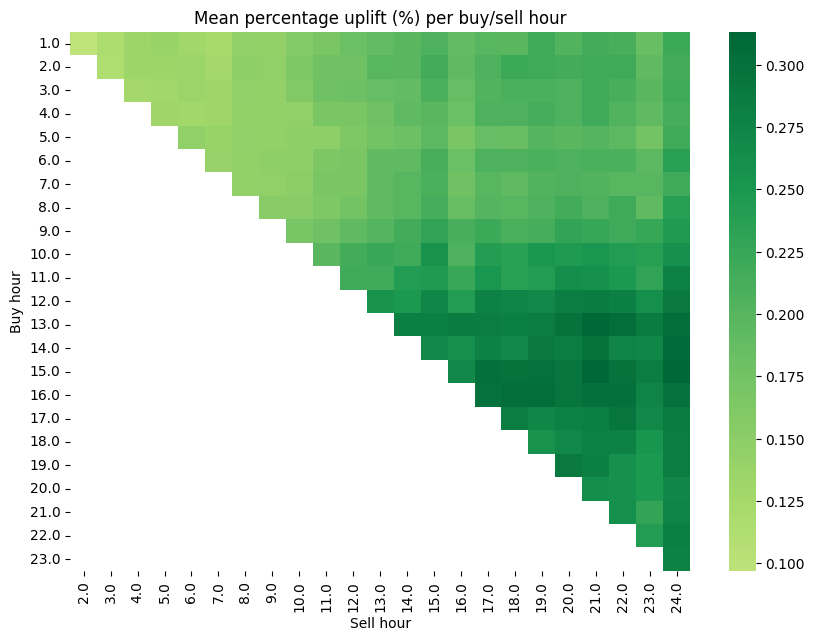

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_pct"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean percentage uplift (%) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


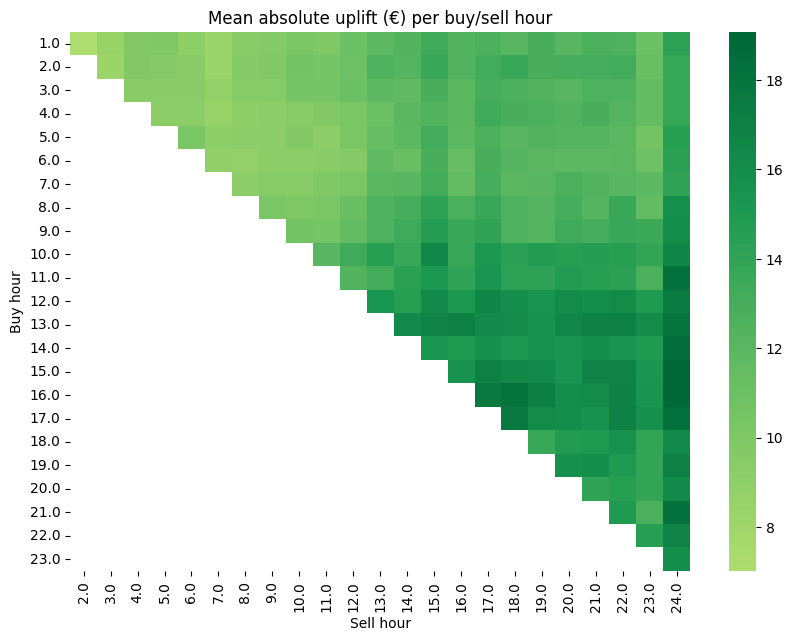

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_abs"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_abs",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean absolute uplift (€) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


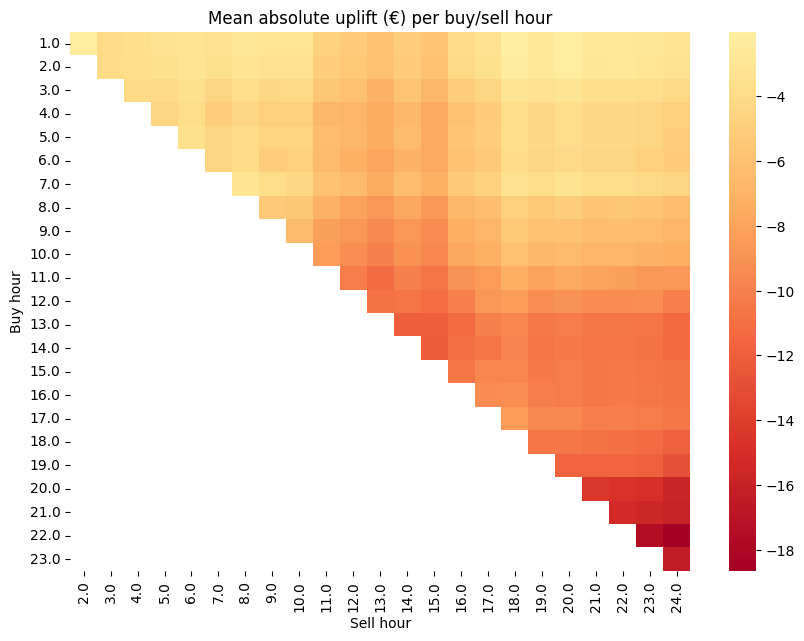

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_abs",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean absolute uplift (€) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

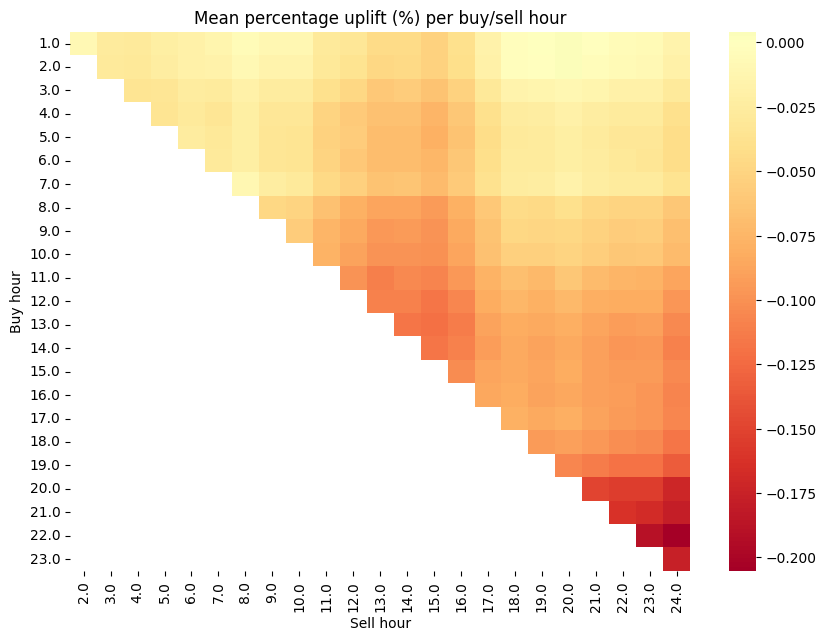

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_mean, cmap="RdYlGn", center=0)
plt.title("Mean percentage uplift (%) per buy/sell hour")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()

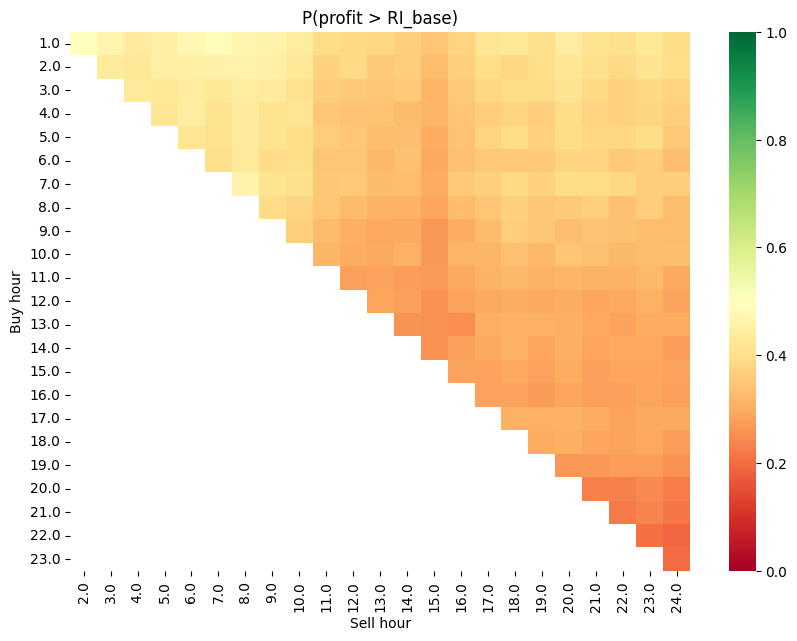

In [132]:
heat_freq = df[df["combo_id"] != 0].assign(
    better=lambda x: x["uplift_abs"] > 0
).pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="better",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_freq, vmin=0, vmax=1,cmap="RdYlGn") #cmap="viridis")
plt.title("P(profit > RI_base)")
plt.xlabel("Sell hour")
plt.ylabel("Buy hour")
plt.show()


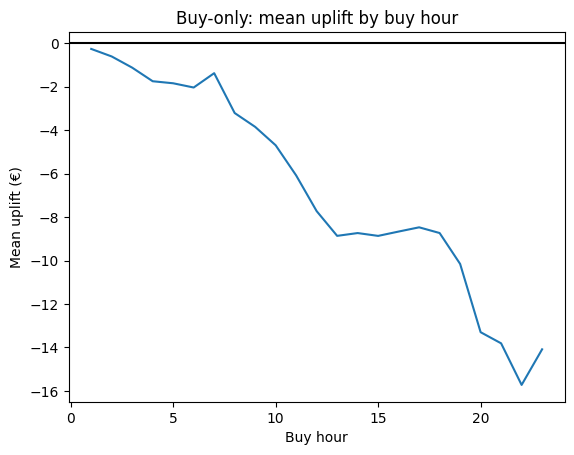

In [157]:
buy_only = df[(df["kind"] == "buy_only") & (df["combo_id"] != 0)]

buy_only_stats = buy_only.groupby("buy_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count",
).reset_index()

buy_only_stats

import matplotlib.pyplot as plt

plt.plot(buy_only_stats["buy_hour"], buy_only_stats["mean"])
plt.axhline(0, color="black")
plt.title("Buy-only: mean uplift by buy hour")
plt.xlabel("Buy hour")
plt.ylabel("Mean uplift (€)")
plt.show()


In [124]:
df["holding_time"] = df["sell_hour"] - df["buy_hour"]

df.groupby("holding_time")["uplift_abs"].agg(
    mean="mean",
    median="median",
    count="count"
).reset_index()


,holding_time,mean,median,count
0,1.0,-8.963258,-5.751974,16790
1,2.0,-8.906199,-5.748900,16060
2,3.0,-8.630944,-5.731475,15330
3,4.0,-8.375005,-5.631107,14600
4,5.0,-8.087982,-5.525230,13870
5,6.0,-7.924942,-5.586906,13140
6,7.0,-7.674668,-5.715429,12410
7,8.0,-7.525456,-5.830536,11680
8,9.0,-7.258281,-5.651509,10950
9,10.0,-7.098717,-5.668467,10220


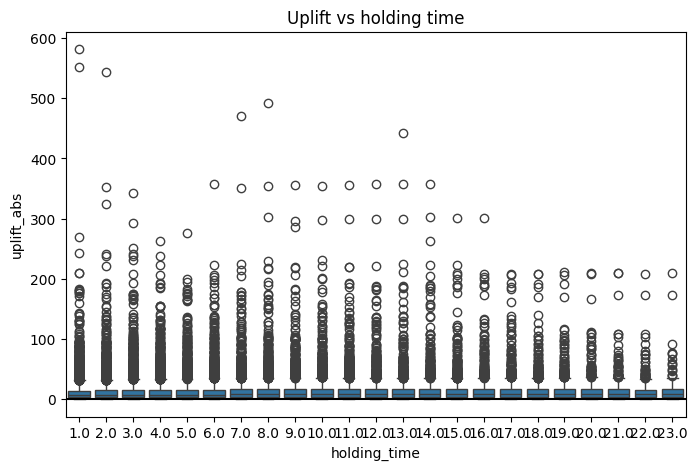

In [125]:
plt.figure(figsize=(8,5))
sns.boxplot(x="holding_time", y="uplift_abs", data=df[df["uplift_abs"]>0])
plt.axhline(0, color="black")
plt.title("Uplift vs holding time")
plt.show()

In [126]:
df.groupby("buy_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)

,mean,median,success_rate,count
buy_hour,,,,
1.0,-3.394992,-1.838052,0.428767,17520
2.0,-3.632141,-2.282578,0.409172,16790
3.0,-4.366370,-2.834275,0.395392,16060
4.0,-5.047403,-3.371546,0.381735,15330
5.0,-4.940320,-3.528758,0.378219,14600
6.0,-5.270045,-3.817121,0.364384,13870
7.0,-4.632059,-3.577020,0.376256,13140
8.0,-6.227911,-5.028818,0.347623,12410
9.0,-7.028112,-5.965997,0.328596,11680


In [127]:

df.groupby("sell_hour")["uplift_abs"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)


,mean,median,success_rate,count
sell_hour,,,,
2.0,-2.243645,0.032663,0.501370,730
3.0,-4.036269,-0.923441,0.447945,1460
4.0,-3.895986,-1.833022,0.430137,2190
5.0,-3.878838,-1.271421,0.436644,2920
6.0,-3.495612,-1.147802,0.446301,3650
7.0,-4.240404,-1.412365,0.430822,4380
8.0,-3.660892,-1.185097,0.445597,5110
9.0,-4.321349,-1.981655,0.421575,5840
10.0,-4.609987,-2.455510,0.405175,6570


In [128]:
q = df["uplift_abs"].quantile(0.95)
top = df[df["uplift_abs"] >= q]

top.groupby(["buy_hour", "sell_hour"]).size().sort_values(ascending=False)


buy_hour  sell_hour
12.0      22.0         54
13.0      24.0         53
12.0      24.0         53
13.0      21.0         52
9.0       24.0         52
                       ..
4.0       11.0         21
1.0       2.0          20
6.0       11.0         19
          12.0         18
5.0       7.0          18
Length: 276, dtype: int64

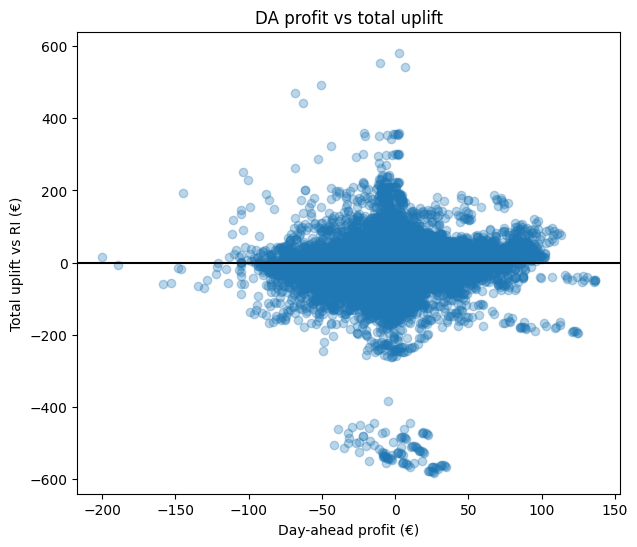

In [129]:
plt.figure(figsize=(7,6))
plt.scatter(df["da_profit"], df["uplift_abs"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Day-ahead profit (€)")
plt.ylabel("Total uplift vs RI (€)")
plt.title("DA profit vs total uplift")
plt.show()


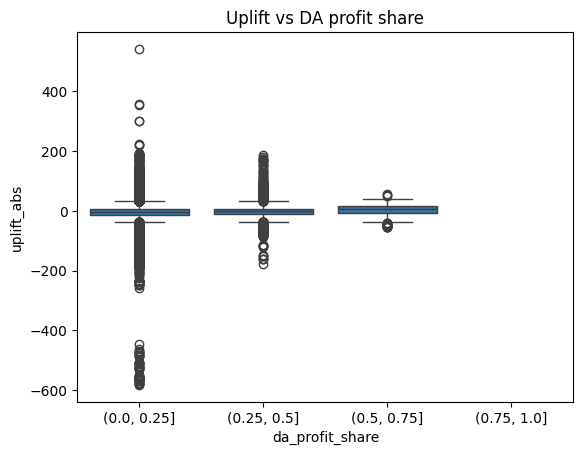

In [130]:
sns.boxplot(x=pd.cut(df["da_profit_share"], bins=[0,0.25,0.5,0.75,1]),
            y=df["uplift_abs"])
plt.title("Uplift vs DA profit share")
plt.show()


In [141]:
g = (df[df.combo_id != 0]
     .groupby(["buy_hour","sell_hour"])
     .apply(lambda x: pd.Series({
         "success_rate": (x.uplift_abs > 0).mean(),
         "mean": x.uplift_abs.mean(),
         "p95": x.uplift_abs.quantile(0.95),
         "p99": x.uplift_abs.quantile(0.99),
         "n": len(x),
     }))
     .reset_index())

pairs = g.to_dict("records")
pareto = []
for i,a in enumerate(pairs):
    dominated = False
    for j,b in enumerate(pairs):
        if i==j: 
            continue
        if (b["success_rate"] >= a["success_rate"] and b["p95"] >= a["p95"]
            and (b["success_rate"] > a["success_rate"] or b["p95"] > a["p95"])):
            dominated = True
            break
    if not dominated:
        pareto.append(a)
pareto_df = pd.DataFrame(pareto).sort_values(["success_rate","p95"], ascending=False)

pareto_df



/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_5152/815439649.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,buy_hour,sell_hour,success_rate,mean,p95,p99,n
0,1.0,2.0,0.501370,-2.243645,16.164223,30.067141,730.0
2,1.0,7.0,0.486301,-3.432758,19.606932,33.047735,730.0
1,1.0,6.0,0.475342,-3.186288,20.993875,32.994338,730.0
3,1.0,8.0,0.467123,-2.902048,22.466905,36.136955,730.0
5,1.0,20.0,0.442466,-2.242848,24.081228,46.688915,730.0
4,1.0,18.0,0.428767,-2.035691,24.862142,40.599717,730.0
7,2.0,20.0,0.420548,-2.307948,25.878735,50.633380,730.0
6,1.0,21.0,0.413699,-2.636212,27.080065,47.575961,730.0
8,2.0,21.0,0.405479,-2.883268,27.774630,47.637936,730.0
9,10.0,24.0,0.332877,-7.370863,28.697362,63.898945,730.0


In [142]:
syn = df[df.combo_id != 0].copy()

topk = (syn.sort_values(["day","uplift_abs"], ascending=[True, False])
          .groupby("day")
          .head(5))

counts = (topk.groupby(["buy_hour","sell_hour"])
              .size()
              .sort_values(ascending=False)
              .head(20))
counts


buy_hour  sell_hour
1.0       2.0          38
          6.0          36
          9.0          36
          8.0          33
          5.0          32
          4.0          31
          3.0          29
5.0       6.0          29
7.0       9.0          28
9.0       10.0         28
1.0       10.0         27
2.0       8.0          27
1.0       18.0         26
3.0       6.0          26
1.0       24.0         26
          7.0          26
7.0       8.0          25
1.0       11.0         24
2.0       4.0          24
          10.0         23
dtype: int64

In [143]:
def cvar(x, alpha=0.1):
    q = x.quantile(alpha)
    return x[x <= q].mean()

risk = (syn.groupby(["buy_hour","sell_hour"])["uplift_abs"]
          .apply(lambda x: pd.Series({
              "mean": x.mean(),
              "cvar10": cvar(x, 0.1),
              "p95": x.quantile(0.95),
              "success": (x>0).mean(),
          }))
          .reset_index())
risk

,buy_hour,sell_hour,level_2,uplift_abs
0,1.0,2.0,mean,-2.243645
1,1.0,2.0,cvar10,-40.149271
2,1.0,2.0,p95,16.164223
3,1.0,2.0,success,0.501370
4,1.0,3.0,mean,-3.997594
...,...,...,...,...
1099,22.0,24.0,success,0.190411
1100,23.0,24.0,mean,-16.390580
1101,23.0,24.0,cvar10,-67.254061
1102,23.0,24.0,p95,20.234541


#### Load drl observation space features

In [94]:


singe_ri_results = pd.read_csv("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv", parse_dates=["day"])
singe_ri_results["day"] = pd.to_datetime(singe_ri_results["day"].astype(str).str.slice(0, 10), errors="coerce")
singe_ri_results["day"] = singe_ri_results["day"].dt.normalize()
singe_ri_results.set_index("day", inplace=True)
singe_ri_results

,profit,cycles
day,,
2019-01-01,68.233139,1.000000
2019-01-02,159.440419,2.000000
2019-01-03,56.598649,3.000000
2019-01-04,64.915423,4.000000
2019-01-05,102.020127,5.000000
...,...,...
2023-09-26,342.531022,1729.536319
2023-09-27,307.205984,1730.536319
2023-09-28,309.449274,1731.536319


In [95]:
summary.set_index("day", inplace=True)
summary = summary.join(singe_ri_results, lsuffix="_oracle", rsuffix="_single_ri")
summary

,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better,profit,cycles
day,,,,,,,,
2019-01-01,68.233139,119.010039,74.416772,142.0,21.450609,17.686777,68.233139,1.0
2019-01-02,159.440419,211.961910,32.941140,168.0,16.861342,17.855675,159.440419,2.0
2019-01-03,56.598649,70.577425,24.698074,38.0,7.912128,5.888537,56.598649,3.0
2019-01-04,64.915423,81.637881,25.760378,29.0,5.272558,3.797980,64.915423,4.0
2019-01-05,102.020127,123.676087,21.227145,3.0,12.765820,10.157263,102.020127,5.0
...,...,...,...,...,...,...,...,...
2020-12-26,108.226402,144.336851,33.365656,67.0,10.348981,7.738395,108.226402,726.0
2020-12-27,150.479823,212.282118,41.070154,182.0,11.218039,10.353632,150.479823,727.0
2020-12-28,130.278365,147.975026,13.583730,192.0,5.773776,5.584448,130.278365,728.0


In [96]:
summary["diff"]= summary["RI_base"] - summary["profit"]

<Axes: title={'center': 'Oracle vs Single RI Profit Comparison'}, xlabel='day'>

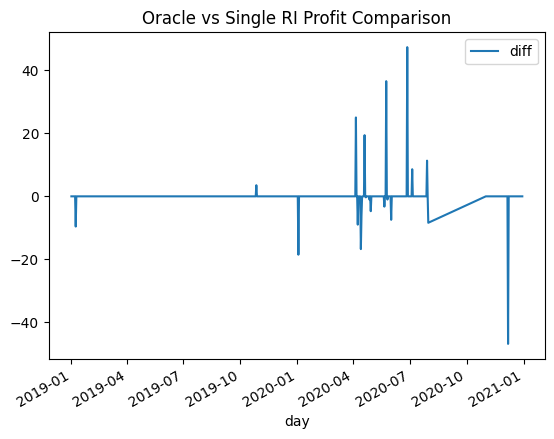

In [102]:
summary.plot(y=["diff"], title="Oracle vs Single RI Profit Comparison")

In [103]:
threshold = 0.01

n_days_diff = (summary["diff"].abs() > threshold).sum()

print(f"Anzahl Tage mit |diff| > {threshold}: {n_days_diff}")


Anzahl Tage mit |diff| > 0.01: 20


In [105]:
summary.loc[summary["diff"].abs() > 0.01].sort_values("diff", ascending=False).head(20)


,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift_pct_if_better,median_uplift_pct_if_better,profit,cycles,diff
day,,,,,,,,,
2020-06-27,89.663991,137.136464,52.944859,78.0,14.358501,9.457176,42.258873,544.0,47.405117
2020-05-24,269.796591,292.425949,8.387563,6.0,3.403450,2.557239,233.197071,510.0,36.599520
2020-04-05,254.178295,291.393171,14.641249,44.0,5.637008,5.566856,229.114149,461.0,25.064146
2020-04-19,200.057040,300.403349,50.158849,207.0,11.195927,9.053527,180.614211,475.0,19.442829
2020-07-29,130.154578,137.049874,5.297775,9.0,2.149203,1.239773,118.816327,576.0,11.338250
2020-07-05,146.181824,216.416131,48.045855,256.0,25.512960,25.572518,137.566705,552.0,8.615119
2019-10-27,124.219292,200.152889,61.128666,257.0,21.685913,20.526463,120.686423,300.0,3.532869
2020-04-21,158.480042,238.783855,50.671247,253.0,20.116278,19.935291,158.790654,477.0,-0.310612
2020-05-26,91.665201,138.832104,51.455625,232.0,19.421921,17.730622,92.683874,512.0,-1.018673
